**Disclosure and oversight joint probability * rewards (0.5)**

In [2]:
!pip install nashpy


/usr/local/lib/python3.12/dist-packages/nashpy/algorithms/support_enumeration.py:260: RuntimeWarning: 
An even number of (6) equilibria was returned. This
indicates that the game is degenerate. Consider using another algorithm
to investigate.
                  
  warnings.warn(warning, RuntimeWarning)


NASH EQUILIBRIA OF THE ASSUMED GAME (A = B = R):
1. Pure
   Developer   : [1.000, 0.000, 0.000]
   Organization: [1.000, 0.000, 0.000]
2. Pure
   Developer   : [0.000, 1.000, 0.000]
   Organization: [0.000, 1.000, 0.000]
3. Pure
   Developer   : [0.000, 0.000, 1.000]
   Organization: [0.000, 0.000, 1.000]
4. Mixed
   Developer   : [0.500, 0.500, 0.000]
   Organization: [0.500, 0.500, 0.000]
5. Mixed
   Developer   : [0.500, 0.000, 0.500]
   Organization: [0.500, 0.000, 0.500]
6. Mixed
   Developer   : [0.000, 0.500, 0.500]
   Organization: [0.000, 0.500, 0.500]

TOPIC-WISE CHECKS:
    Family                           Topic   Developer candidate Organization candidate Developer pure payoffs Organization pure payoffs  Developer BR Organization BR          Mutual BR alignments Candidate mixed Nash?
Disclosure                   Usage Pattern [0.053, 0.368, 0.579]  [0.071, 0.643, 0.286]  [0.393, 0.821, 0.607]     [0.237, 0.684, 0.763]       Partial            Full               (Partial, Fu

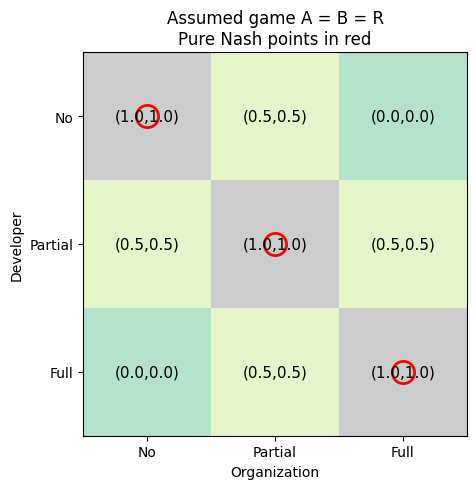

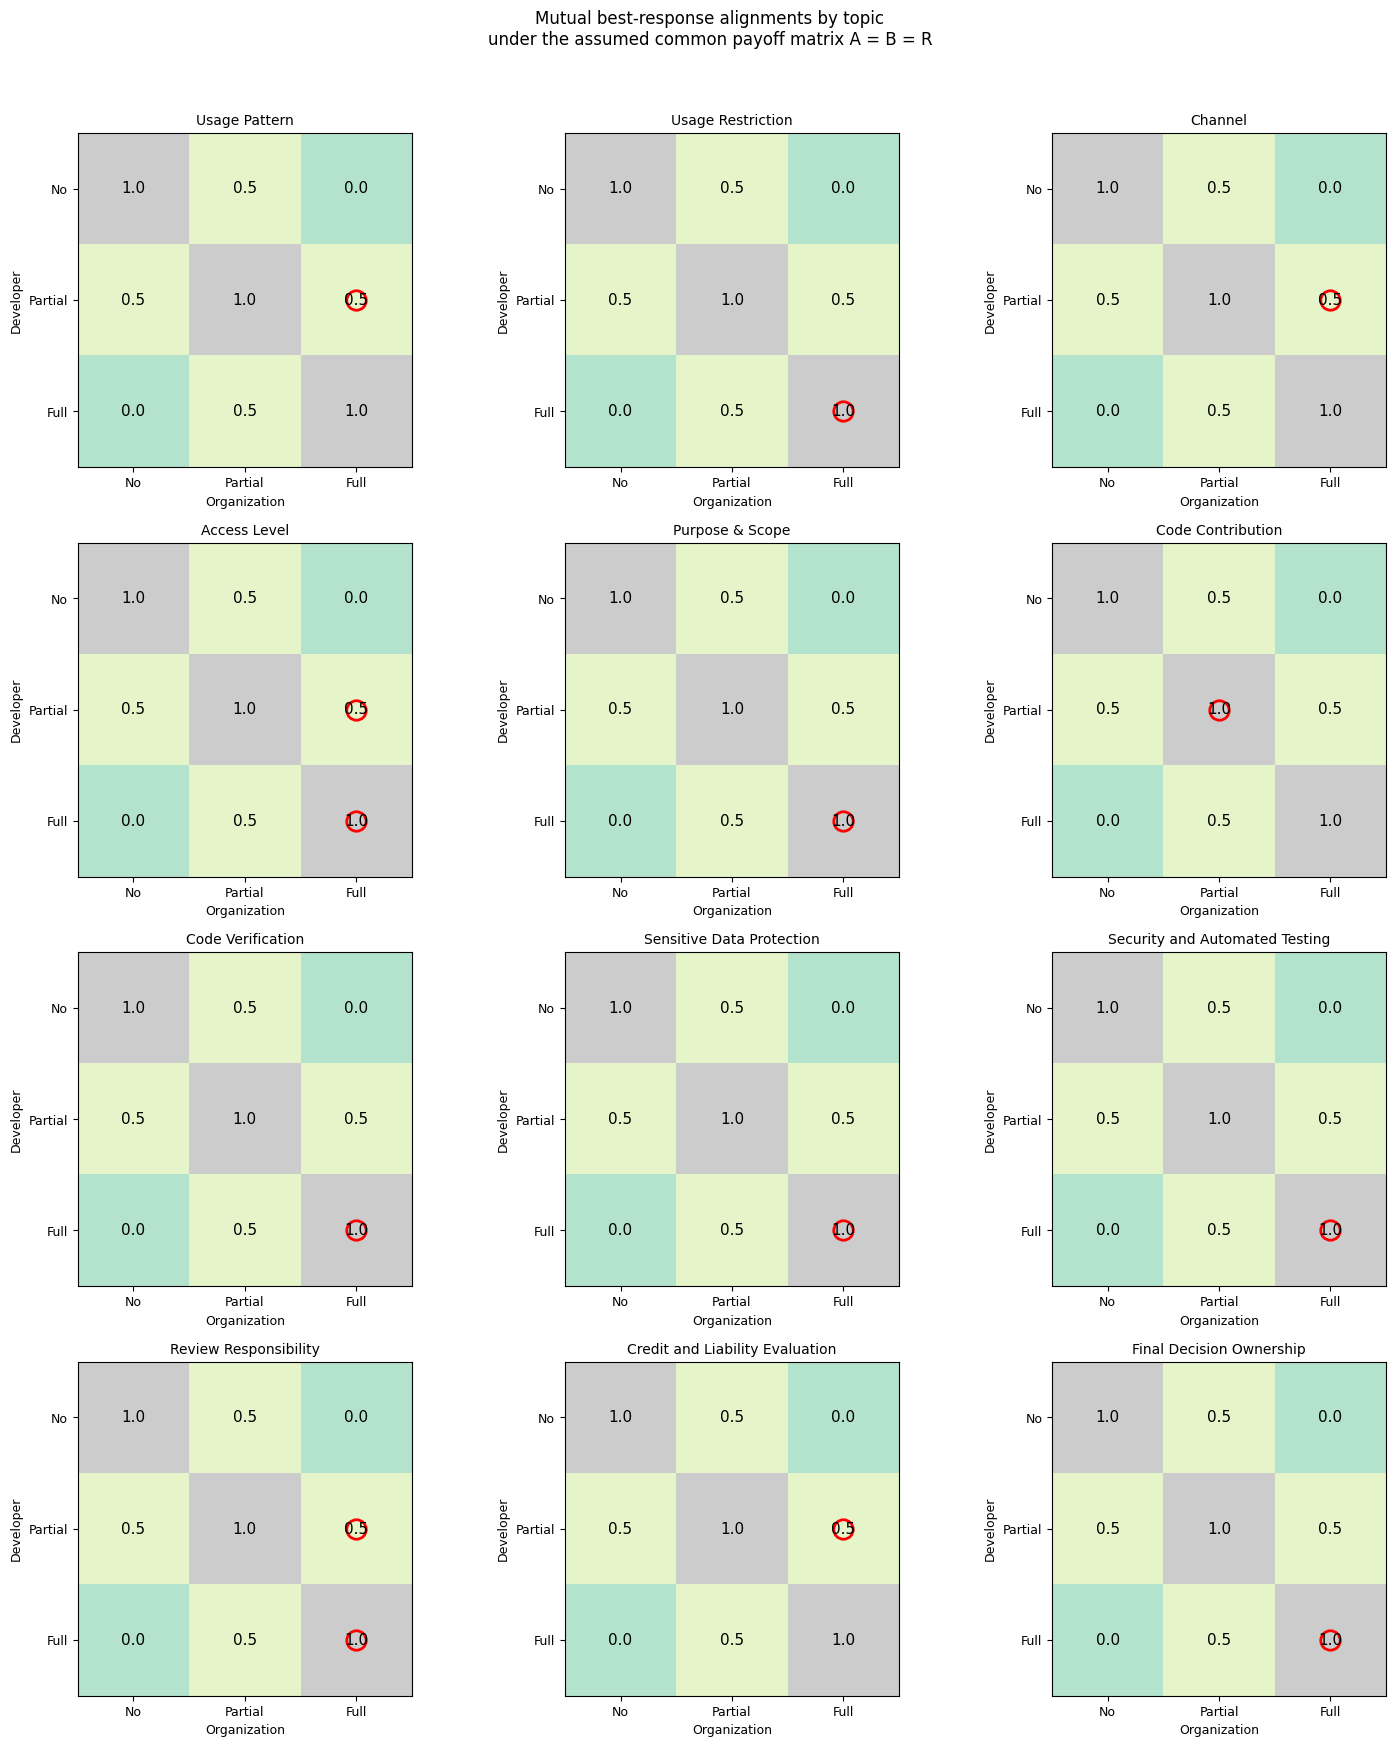

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import nashpy as nash

# ---------- data ----------
topics_disclosure = [
    "Usage Pattern",
    "Usage Restriction",
    "Channel",
    "Access Level",
    "Purpose & Scope",
    "Code Contribution",
]

developer_counts_disclosure = {
    "Usage Pattern":     {"No": 1, "Partial": 7, "Full": 11},
    "Usage Restriction": {"No": 2, "Partial": 4, "Full": 13},
    "Channel":           {"No": 0, "Partial": 6, "Full": 13},
    "Access Level":      {"No": 1, "Partial": 6, "Full": 12},
    "Purpose & Scope":   {"No": 0, "Partial": 8, "Full": 11},
    "Code Contribution": {"No": 0, "Partial": 12, "Full": 7},
}

organization_counts_disclosure = {
    "Usage Pattern":     {"No": 1, "Partial": 9, "Full": 4},
    "Usage Restriction": {"No": 1, "Partial": 5, "Full": 8},
    "Channel":           {"No": 2, "Partial": 6, "Full": 6},
    "Access Level":      {"No": 2, "Partial": 5, "Full": 7},
    "Purpose & Scope":   {"No": 2, "Partial": 4, "Full": 8},
    "Code Contribution": {"No": 1, "Partial": 8, "Full": 5},
}

topics_oversight = [
    "Code Verification",
    "Sensitive Data Protection",
    "Security and Automated Testing",
    "Review Responsibility",
    "Credit and Liability Evaluation",
    "Final Decision Ownership",
]

developer_counts_oversight = {
    "Code Verification":               {"No": 0, "Partial": 5, "Full": 14},
    "Sensitive Data Protection":       {"No": 0, "Partial": 0, "Full": 19},
    "Security and Automated Testing":  {"No": 0, "Partial": 4, "Full": 15},
    "Review Responsibility":           {"No": 1, "Partial": 7, "Full": 11},
    "Credit and Liability Evaluation": {"No": 0, "Partial": 5, "Full": 14},
    "Final Decision Ownership":        {"No": 0, "Partial": 1, "Full": 18},
}

organization_counts_oversight = {
    "Code Verification":               {"No": 0, "Partial": 3, "Full": 11},
    "Sensitive Data Protection":       {"No": 0, "Partial": 2, "Full": 12},
    "Security and Automated Testing":  {"No": 0, "Partial": 5, "Full": 9},
    "Review Responsibility":           {"No": 0, "Partial": 7, "Full": 7},
    "Credit and Liability Evaluation": {"No": 0, "Partial": 8, "Full": 6},
    "Final Decision Ownership":        {"No": 0, "Partial": 1, "Full": 13},
}

order = ["No", "Partial", "Full"]

# ---------- helpers ----------
def probs(counts_dict, order):
    v = np.array([counts_dict[k] for k in order], dtype=float)
    s = v.sum()
    return v / s if s > 0 else np.zeros_like(v)

def is_pure_strategy(sig, tol=1e-9):
    return np.max(sig) >= 1 - tol and np.isclose(sig.sum(), 1.0, atol=tol)

def strategy_to_str(sig):
    return "[" + ", ".join(f"{x:.3f}" for x in sig) + "]"

# ---------- assumed common payoff matrix ----------
rho = 0.5
R = np.array([
    [1.0, rho, 0.0],
    [rho, 1.0, rho],
    [0.0, rho, 1.0],
], dtype=float)

# Assumption: same payoff matrix for both players
A = R.copy()   # Developer payoff matrix
B = R.copy()   # Organization payoff matrix

# ---------- Nash equilibria of the assumed game ----------
game = nash.Game(A, B)

equilibria = []
for sigma_r, sigma_c in game.support_enumeration():
    sigma_r = np.array(sigma_r, dtype=float)
    sigma_c = np.array(sigma_c, dtype=float)

    # deduplicate because degenerate games can repeat solutions numerically
    duplicate = False
    for er, ec in equilibria:
        if np.allclose(sigma_r, er, atol=1e-9) and np.allclose(sigma_c, ec, atol=1e-9):
            duplicate = True
            break
    if not duplicate:
        equilibria.append((sigma_r, sigma_c))

print("NASH EQUILIBRIA OF THE ASSUMED GAME (A = B = R):")
for idx, (sr, sc) in enumerate(equilibria, start=1):
    kind = "Pure" if is_pure_strategy(sr) and is_pure_strategy(sc) else "Mixed"
    print(f"{idx}. {kind}")
    print(f"   Developer   : {strategy_to_str(sr)}")
    print(f"   Organization: {strategy_to_str(sc)}")

# ---------- candidate checks using survey-normalized profiles ----------
def check_candidate_profile(pD, pO, A, B, tol=1e-9):
    """
    Treat pD and pO as candidate mixed strategies and check whether
    they form a mixed-strategy Nash equilibrium under A and B.
    Also compute mutual best-response pure alignments.
    """
    # expected payoff to each pure action
    dev_pure_payoffs = A @ pO
    org_pure_payoffs = pD @ B

    # supports
    dev_support = np.where(pD > tol)[0]
    org_support = np.where(pO > tol)[0]

    # equilibrium-check conditions
    dev_support_equal = np.allclose(
        dev_pure_payoffs[dev_support],
        dev_pure_payoffs[dev_support][0],
        atol=tol
    ) if len(dev_support) > 0 else False

    org_support_equal = np.allclose(
        org_pure_payoffs[org_support],
        org_pure_payoffs[org_support][0],
        atol=tol
    ) if len(org_support) > 0 else False

    dev_unused = np.where(pD <= tol)[0]
    org_unused = np.where(pO <= tol)[0]

    dev_unused_ok = np.all(
        dev_pure_payoffs[dev_unused] <= dev_pure_payoffs[dev_support][0] + tol
    ) if len(dev_support) > 0 and len(dev_unused) > 0 else True

    org_unused_ok = np.all(
        org_pure_payoffs[org_unused] <= org_pure_payoffs[org_support][0] + tol
    ) if len(org_support) > 0 and len(org_unused) > 0 else True

    candidate_is_mixed_nash = (
        dev_support_equal and org_support_equal and dev_unused_ok and org_unused_ok
    )

    # mutual best-response pure alignments
    dev_best = np.where(dev_pure_payoffs >= dev_pure_payoffs.max() - tol)[0]
    org_best = np.where(org_pure_payoffs >= org_pure_payoffs.max() - tol)[0]
    alignments = [(order[i], order[j]) for i in dev_best for j in org_best]

    return {
        "dev_pure_payoffs": dev_pure_payoffs,
        "org_pure_payoffs": org_pure_payoffs,
        "dev_best": dev_best,
        "org_best": org_best,
        "alignments": alignments,
        "candidate_is_mixed_nash": candidate_is_mixed_nash,
    }

all_rows = []

for family, topics, dcounts, ocounts in [
    ("Disclosure", topics_disclosure, developer_counts_disclosure, organization_counts_disclosure),
    ("Oversight", topics_oversight, developer_counts_oversight, organization_counts_oversight),
]:
    for topic in topics:
        pD = probs(dcounts[topic], order)
        pO = probs(ocounts[topic], order)
        out = check_candidate_profile(pD, pO, A, B)

        all_rows.append({
            "Family": family,
            "Topic": topic,
            "Developer candidate": strategy_to_str(pD),
            "Organization candidate": strategy_to_str(pO),
            "Developer pure payoffs": strategy_to_str(out["dev_pure_payoffs"]),
            "Organization pure payoffs": strategy_to_str(out["org_pure_payoffs"]),
            "Developer BR": ", ".join(order[i] for i in out["dev_best"]),
            "Organization BR": ", ".join(order[j] for j in out["org_best"]),
            "Mutual BR alignments": "; ".join(f"({a}, {b})" for a, b in out["alignments"]),
            "Candidate mixed Nash?": "Yes" if out["candidate_is_mixed_nash"] else "No",
        })

df = pd.DataFrame(all_rows)
print("\nTOPIC-WISE CHECKS:")
print(df.to_string(index=False))

# optional save
df.to_csv("nash_candidate_checks_common_R.csv", index=False)

# ---------- visualization 1: payoff matrix and pure Nash points ----------
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(A, cmap="Pastel2")

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"({A[i,j]:.1f},{B[i,j]:.1f})",
                ha="center", va="center", fontsize=11)

# mark pure Nash equilibria
for sr, sc in equilibria:
    if is_pure_strategy(sr) and is_pure_strategy(sc):
        i = int(np.argmax(sr))
        j = int(np.argmax(sc))
        ax.plot(j, i, marker="o", markersize=16,
                markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(order)
ax.set_yticklabels(order)
ax.set_xlabel("Organization")
ax.set_ylabel("Developer")
ax.set_title("Assumed game A = B = R\nPure Nash points in red")
plt.tight_layout()
plt.show()

# ---------- visualization 2: topic-wise mutual BR alignments ----------
n = len(all_rows)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.4 * nrows))
axes = np.atleast_2d(axes)

for idx, row in enumerate(all_rows):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    ax.imshow(A, cmap="Pastel2")

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{A[i,j]:.1f}", ha="center", va="center", fontsize=11)

    topic = row["Topic"]
    family = row["Family"]

    if family == "Disclosure":
        pD = probs(developer_counts_disclosure[topic], order)
        pO = probs(organization_counts_disclosure[topic], order)
    else:
        pD = probs(developer_counts_oversight[topic], order)
        pO = probs(organization_counts_oversight[topic], order)

    out = check_candidate_profile(pD, pO, A, B)

    for i in out["dev_best"]:
        for j in out["org_best"]:
            ax.plot(j, i, marker="o", markersize=14,
                    markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(order, fontsize=9)
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel("Organization", fontsize=9)
    ax.set_ylabel("Developer", fontsize=9)
    ax.set_title(topic, fontsize=10)

for k in range(n, nrows * ncols):
    r, c = divmod(k, ncols)
    fig.delaxes(axes[r, c])

fig.suptitle("Mutual best-response alignments by topic\nunder the assumed common payoff matrix A = B = R", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Disclosure and oversight joint probability * reward (0.4, 0.6)**


ANALYSIS FOR rho = 0.4

PURE NASH EQUILIBRIA OF THE ASSUMED GAME A = B = R:
(No, No)
(Partial, Partial)
(Full, Full)

SYMMETRIC MIXED EQUILIBRIA OF THE ASSUMED GAME:
Developer = [0.500, 0.500, 0.000], Organization = [0.500, 0.500, 0.000]
Developer = [0.500, 0.000, 0.500], Organization = [0.500, 0.000, 0.500]
Developer = [0.000, 0.500, 0.500], Organization = [0.000, 0.500, 0.500]

TOPIC-WISE CHECKS:
    Family                           Topic   Developer candidate Organization candidate Developer pure payoffs Organization pure payoffs  Developer BR Organization BR          Mutual BR alignments Candidate mixed Nash?
Disclosure                   Usage Pattern [0.053, 0.368, 0.579]  [0.071, 0.643, 0.286]  [0.329, 0.786, 0.543]     [0.200, 0.621, 0.726]       Partial            Full               (Partial, Full)                    No
Disclosure               Usage Restriction [0.105, 0.211, 0.684]  [0.071, 0.357, 0.571]  [0.214, 0.614, 0.714]     [0.189, 0.526, 0.768]          Full         

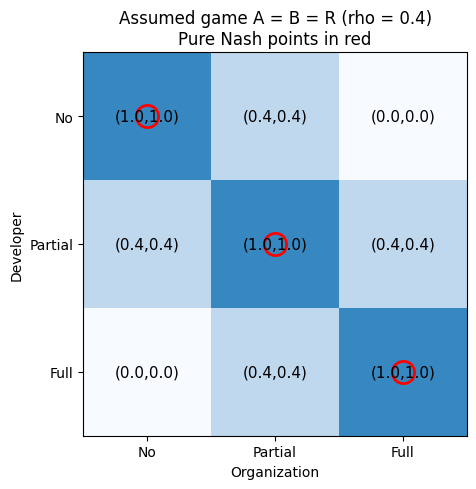

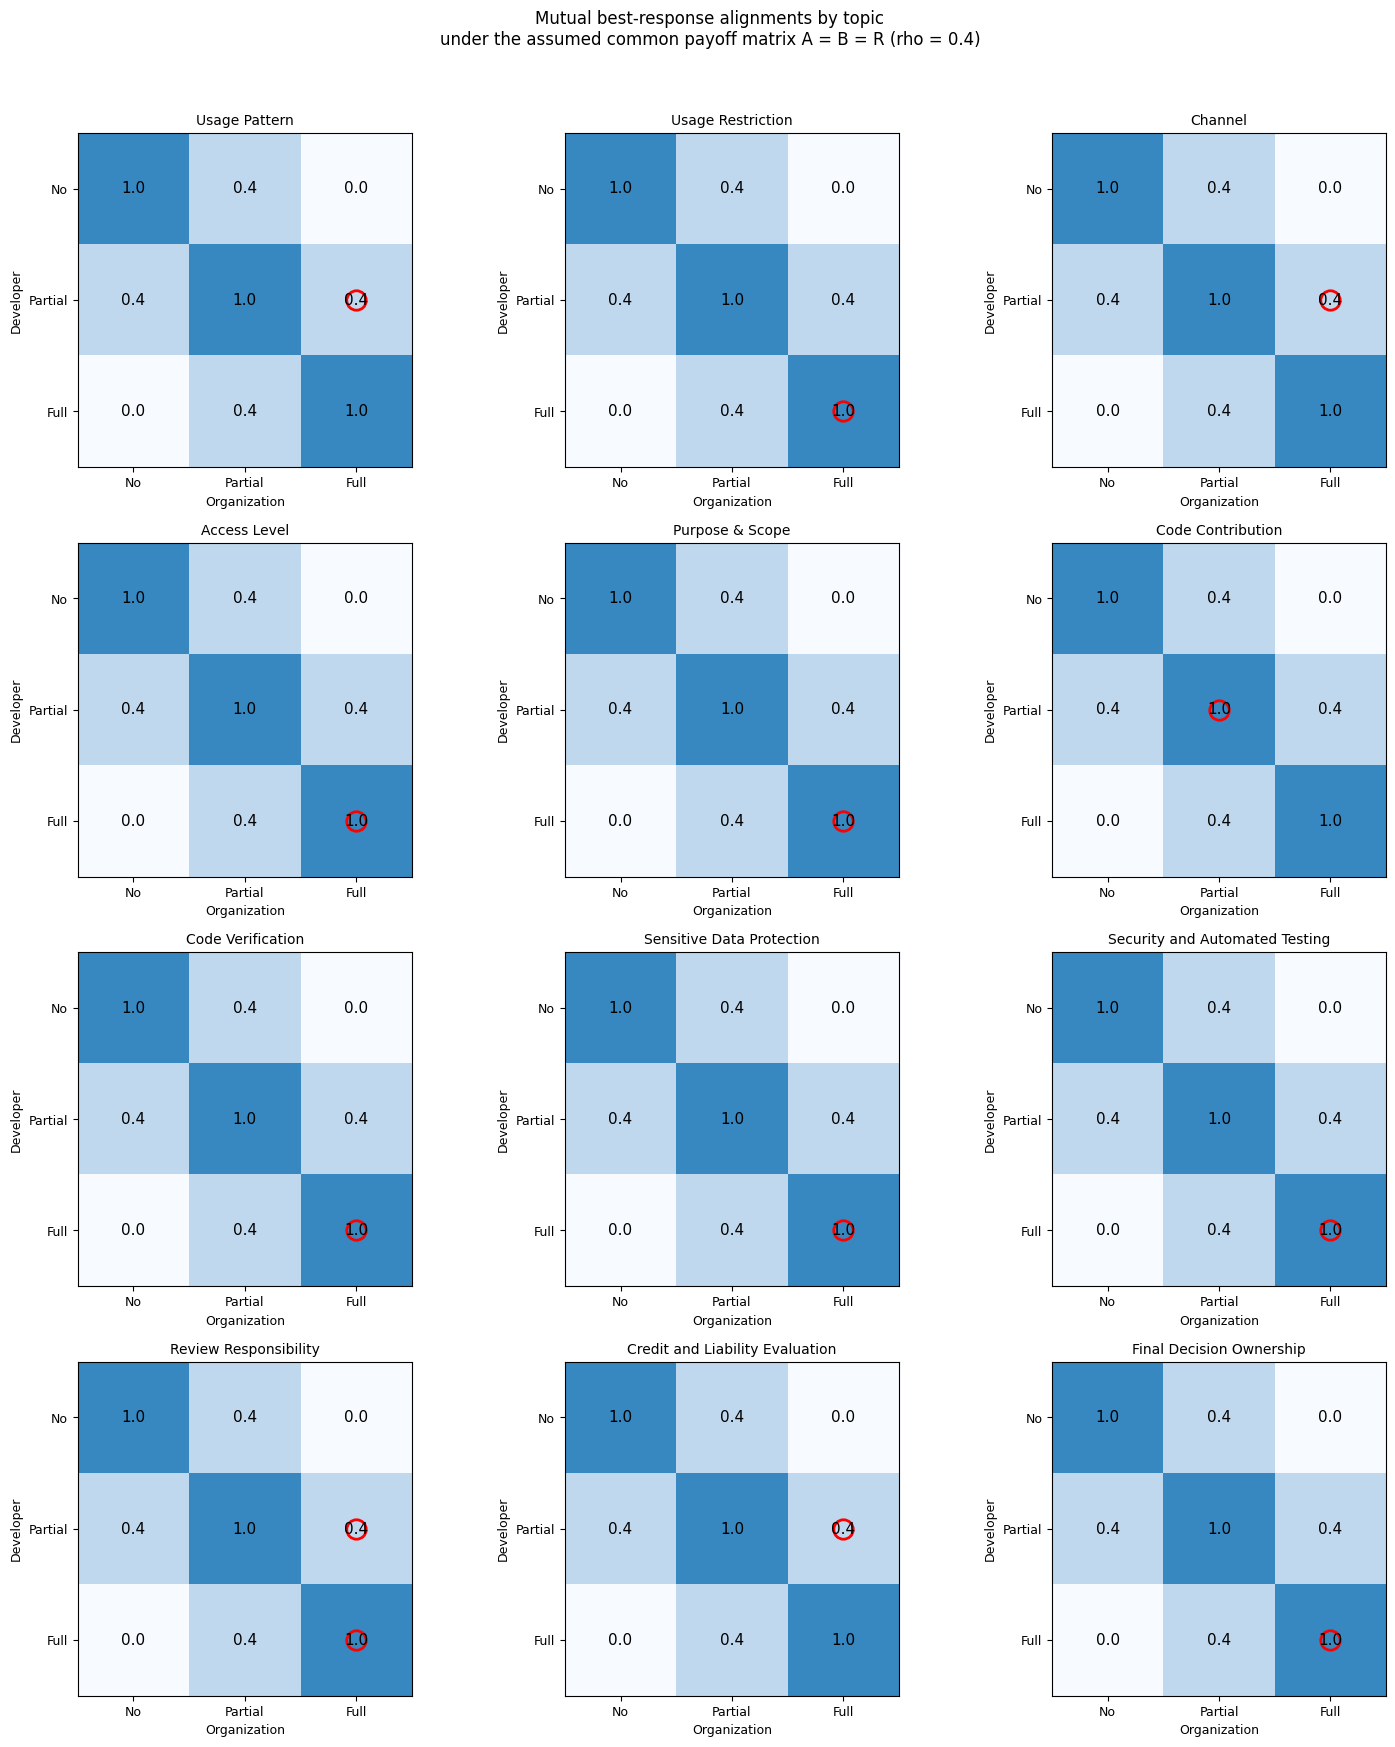


ANALYSIS FOR rho = 0.6

PURE NASH EQUILIBRIA OF THE ASSUMED GAME A = B = R:
(No, No)
(Partial, Partial)
(Full, Full)

SYMMETRIC MIXED EQUILIBRIA OF THE ASSUMED GAME:
Developer = [0.500, 0.500, 0.000], Organization = [0.500, 0.500, 0.000]
Developer = [0.500, 0.000, 0.500], Organization = [0.500, 0.000, 0.500]
Developer = [0.000, 0.500, 0.500], Organization = [0.000, 0.500, 0.500]

TOPIC-WISE CHECKS:
    Family                           Topic   Developer candidate Organization candidate Developer pure payoffs Organization pure payoffs  Developer BR Organization BR          Mutual BR alignments Candidate mixed Nash?
Disclosure                   Usage Pattern [0.053, 0.368, 0.579]  [0.071, 0.643, 0.286]  [0.457, 0.857, 0.671]     [0.274, 0.747, 0.800]       Partial            Full               (Partial, Full)                    No
Disclosure               Usage Restriction [0.105, 0.211, 0.684]  [0.071, 0.357, 0.571]  [0.286, 0.743, 0.786]     [0.232, 0.684, 0.811]          Full         

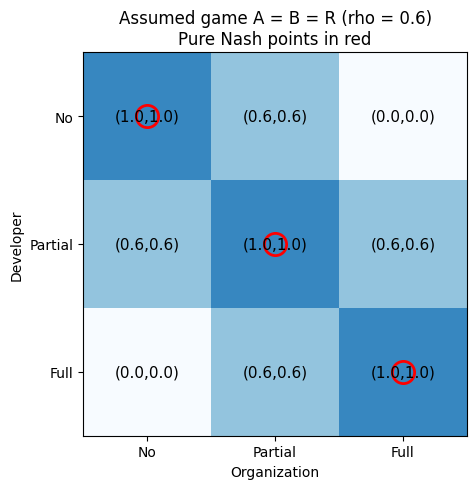

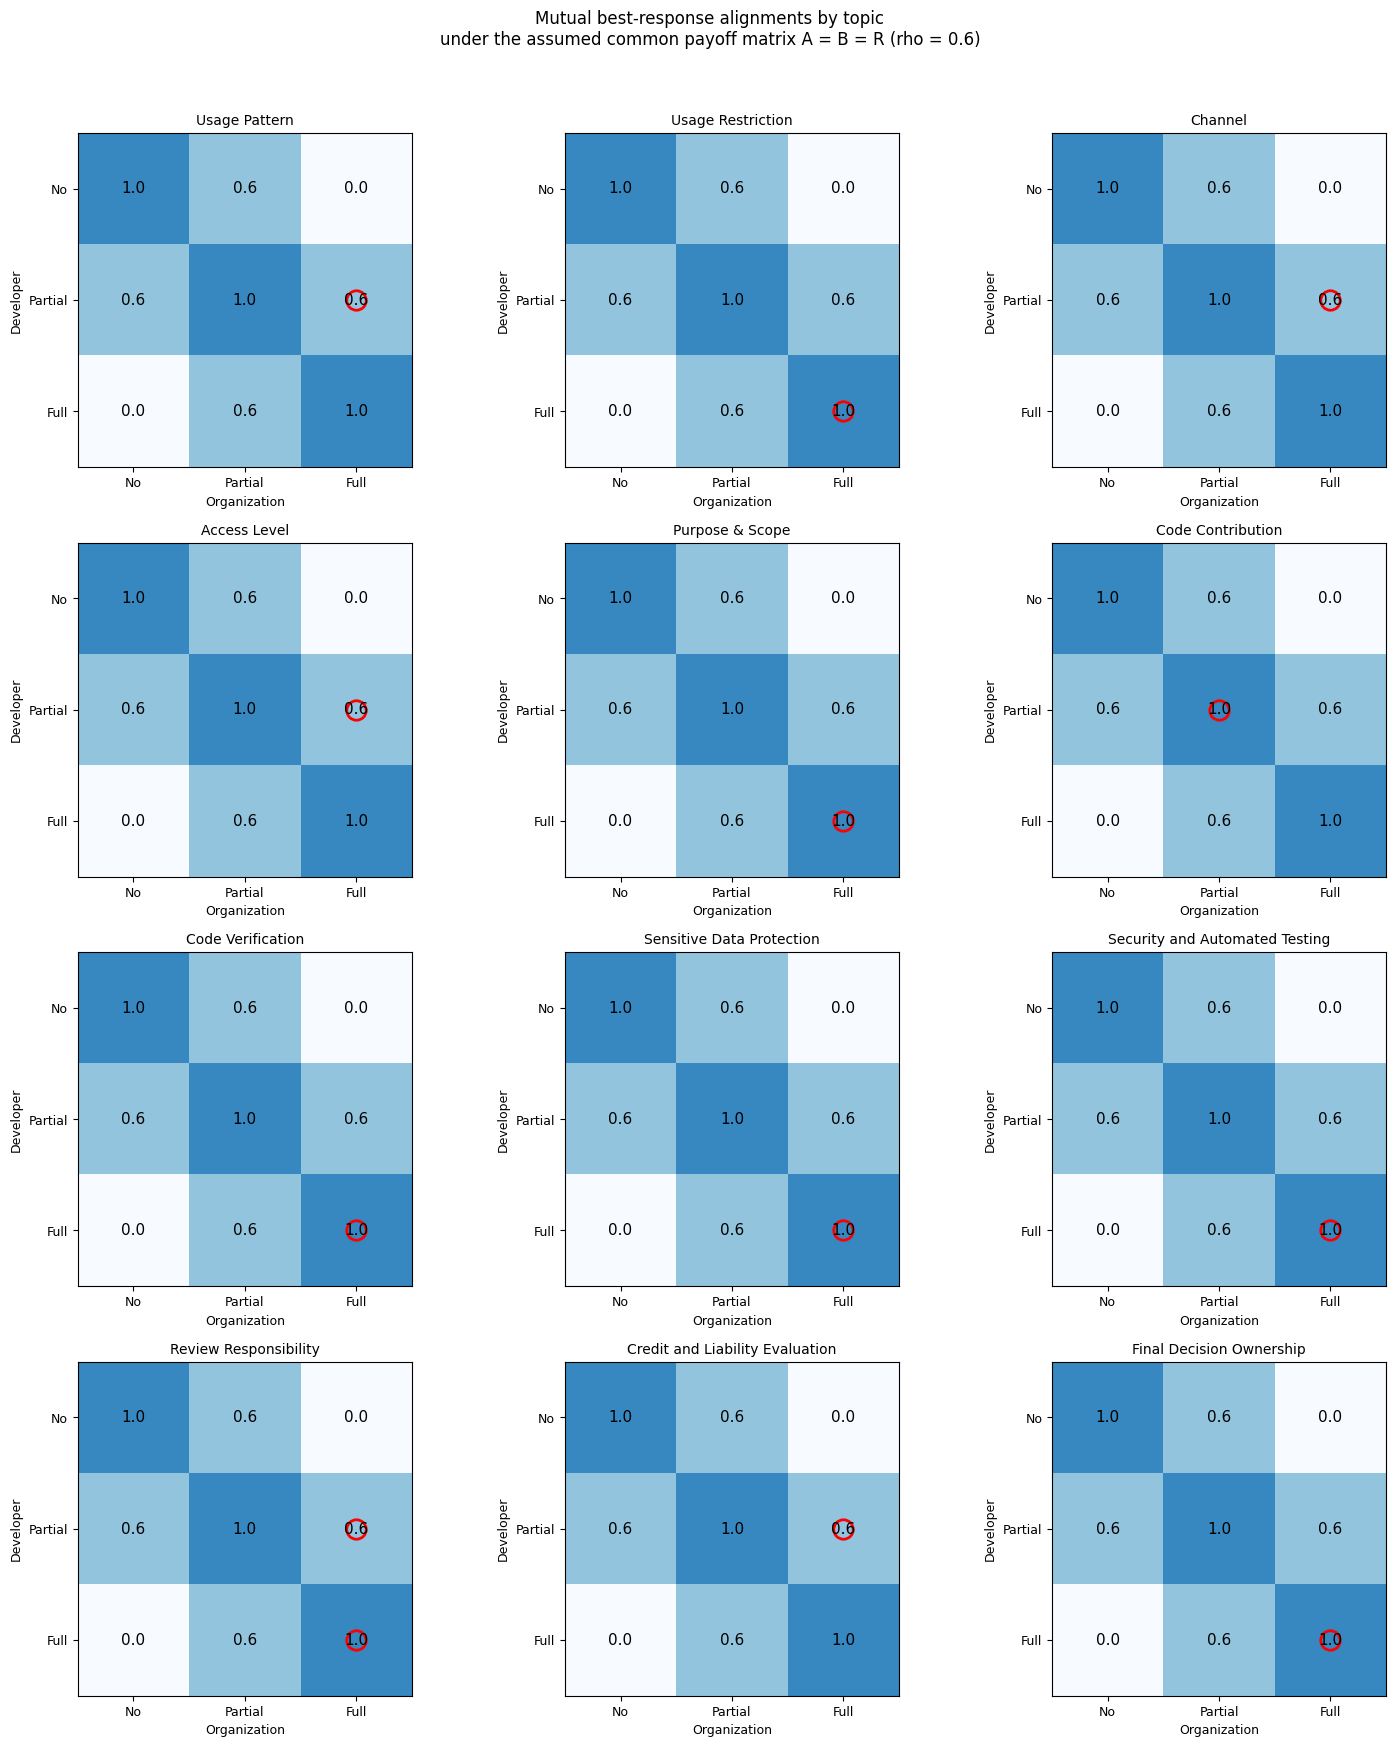

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ---------- data ----------
topics_disclosure = [
    "Usage Pattern",
    "Usage Restriction",
    "Channel",
    "Access Level",
    "Purpose & Scope",
    "Code Contribution",
]

developer_counts_disclosure = {
    "Usage Pattern":     {"No": 1, "Partial": 7, "Full": 11},
    "Usage Restriction": {"No": 2, "Partial": 4, "Full": 13},
    "Channel":           {"No": 0, "Partial": 6, "Full": 13},
    "Access Level":      {"No": 1, "Partial": 6, "Full": 12},
    "Purpose & Scope":   {"No": 0, "Partial": 8, "Full": 11},
    "Code Contribution": {"No": 0, "Partial": 12, "Full": 7},
}

organization_counts_disclosure = {
    "Usage Pattern":     {"No": 1, "Partial": 9, "Full": 4},
    "Usage Restriction": {"No": 1, "Partial": 5, "Full": 8},
    "Channel":           {"No": 2, "Partial": 6, "Full": 6},
    "Access Level":      {"No": 2, "Partial": 5, "Full": 7},
    "Purpose & Scope":   {"No": 2, "Partial": 4, "Full": 8},
    "Code Contribution": {"No": 1, "Partial": 8, "Full": 5},
}

topics_oversight = [
    "Code Verification",
    "Sensitive Data Protection",
    "Security and Automated Testing",
    "Review Responsibility",
    "Credit and Liability Evaluation",
    "Final Decision Ownership",
]

developer_counts_oversight = {
    "Code Verification":               {"No": 0, "Partial": 5, "Full": 14},
    "Sensitive Data Protection":       {"No": 0, "Partial": 0, "Full": 19},
    "Security and Automated Testing":  {"No": 0, "Partial": 4, "Full": 15},
    "Review Responsibility":           {"No": 1, "Partial": 7, "Full": 11},
    "Credit and Liability Evaluation": {"No": 0, "Partial": 5, "Full": 14},
    "Final Decision Ownership":        {"No": 0, "Partial": 1, "Full": 18},
}

organization_counts_oversight = {
    "Code Verification":               {"No": 0, "Partial": 3, "Full": 11},
    "Sensitive Data Protection":       {"No": 0, "Partial": 2, "Full": 12},
    "Security and Automated Testing":  {"No": 0, "Partial": 5, "Full": 9},
    "Review Responsibility":           {"No": 0, "Partial": 7, "Full": 7},
    "Credit and Liability Evaluation": {"No": 0, "Partial": 8, "Full": 6},
    "Final Decision Ownership":        {"No": 0, "Partial": 1, "Full": 13},
}

order = ["No", "Partial", "Full"]

# ---------- helpers ----------
def probs(counts_dict, order):
    v = np.array([counts_dict[k] for k in order], dtype=float)
    s = v.sum()
    return v / s if s > 0 else np.zeros_like(v)

def strategy_to_str(sig):
    return "[" + ", ".join(f"{x:.3f}" for x in sig) + "]"

def pure_nash_equilibria(A, B, tol=1e-12):
    eqs = []
    n_rows, n_cols = A.shape
    for i in range(n_rows):
        for j in range(n_cols):
            row_payoff = A[:, j]
            col_payoff = B[i, :]
            if A[i, j] >= row_payoff.max() - tol and B[i, j] >= col_payoff.max() - tol:
                eqs.append((i, j))
    return eqs

def check_candidate_profile(pD, pO, A, B, tol=1e-9):
    dev_pure_payoffs = A @ pO
    org_pure_payoffs = pD @ B

    dev_support = np.where(pD > tol)[0]
    org_support = np.where(pO > tol)[0]

    dev_support_equal = np.allclose(
        dev_pure_payoffs[dev_support],
        dev_pure_payoffs[dev_support][0],
        atol=tol
    ) if len(dev_support) > 0 else False

    org_support_equal = np.allclose(
        org_pure_payoffs[org_support],
        org_pure_payoffs[org_support][0],
        atol=tol
    ) if len(org_support) > 0 else False

    dev_unused = np.where(pD <= tol)[0]
    org_unused = np.where(pO <= tol)[0]

    dev_unused_ok = np.all(
        dev_pure_payoffs[dev_unused] <= dev_pure_payoffs[dev_support][0] + tol
    ) if len(dev_support) > 0 and len(dev_unused) > 0 else True

    org_unused_ok = np.all(
        org_pure_payoffs[org_unused] <= org_pure_payoffs[org_support][0] + tol
    ) if len(org_support) > 0 and len(org_unused) > 0 else True

    candidate_is_mixed_nash = (
        dev_support_equal and org_support_equal and dev_unused_ok and org_unused_ok
    )

    dev_best = np.where(dev_pure_payoffs >= dev_pure_payoffs.max() - tol)[0]
    org_best = np.where(org_pure_payoffs >= org_pure_payoffs.max() - tol)[0]
    alignments = [(order[i], order[j]) for i in dev_best for j in org_best]

    return {
        "dev_pure_payoffs": dev_pure_payoffs,
        "org_pure_payoffs": org_pure_payoffs,
        "dev_best": dev_best,
        "org_best": org_best,
        "alignments": alignments,
        "candidate_is_mixed_nash": candidate_is_mixed_nash,
    }

def analyze_for_rho(rho):
    print("\n" + "="*80)
    print(f"ANALYSIS FOR rho = {rho}")
    print("="*80)

    # assumed common payoff matrix
    R = np.array([
        [1.0, rho, 0.0],
        [rho, 1.0, rho],
        [0.0, rho, 1.0],
    ], dtype=float)

    A = R.copy()
    B = R.copy()

    # ---------- pure Nash equilibria ----------
    pure_eqs = pure_nash_equilibria(A, B)

    print("\nPURE NASH EQUILIBRIA OF THE ASSUMED GAME A = B = R:")
    for i, j in pure_eqs:
        print(f"({order[i]}, {order[j]})")

    # ---------- symmetric mixed equilibria for this coordination structure ----------
    mixed_eqs = [
        np.array([0.5, 0.5, 0.0]),
        np.array([0.5, 0.0, 0.5]),
        np.array([0.0, 0.5, 0.5]),
    ]

    print("\nSYMMETRIC MIXED EQUILIBRIA OF THE ASSUMED GAME:")
    for sig in mixed_eqs:
        print(f"Developer = {strategy_to_str(sig)}, Organization = {strategy_to_str(sig)}")

    # ---------- candidate checks ----------
    all_rows = []

    for family, topics, dcounts, ocounts in [
        ("Disclosure", topics_disclosure, developer_counts_disclosure, organization_counts_disclosure),
        ("Oversight", topics_oversight, developer_counts_oversight, organization_counts_oversight),
    ]:
        for topic in topics:
            pD = probs(dcounts[topic], order)
            pO = probs(ocounts[topic], order)
            out = check_candidate_profile(pD, pO, A, B)

            all_rows.append({
                "Family": family,
                "Topic": topic,
                "Developer candidate": strategy_to_str(pD),
                "Organization candidate": strategy_to_str(pO),
                "Developer pure payoffs": strategy_to_str(out["dev_pure_payoffs"]),
                "Organization pure payoffs": strategy_to_str(out["org_pure_payoffs"]),
                "Developer BR": ", ".join(order[i] for i in out["dev_best"]),
                "Organization BR": ", ".join(order[j] for j in out["org_best"]),
                "Mutual BR alignments": "; ".join(f"({a}, {b})" for a, b in out["alignments"]),
                "Candidate mixed Nash?": "Yes" if out["candidate_is_mixed_nash"] else "No",
            })

    df = pd.DataFrame(all_rows)

    print("\nTOPIC-WISE CHECKS:")
    print(df.to_string(index=False))

    # optional save
    df.to_csv(f"nash_candidate_checks_rho_{str(rho).replace('.', '_')}.csv", index=False)

    # ---------- visualization 1: payoff matrix ----------
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(A, cmap="Blues", vmin=0, vmax=1.5)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"({A[i,j]:.1f},{B[i,j]:.1f})",
                    ha="center", va="center", fontsize=11)

    for i, j in pure_eqs:
        ax.plot(j, i, marker="o", markersize=16,
                markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(order)
    ax.set_yticklabels(order)
    ax.set_xlabel("Organization")
    ax.set_ylabel("Developer")
    ax.set_title(f"Assumed game A = B = R (rho = {rho})\nPure Nash points in red")
    plt.tight_layout()
    plt.show()

    # ---------- visualization 2: topic-wise mutual BR alignments ----------
    n = len(all_rows)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.4 * nrows))
    axes = np.atleast_2d(axes)

    for idx, row in enumerate(all_rows):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        ax.imshow(A, cmap="Blues", vmin=0, vmax=1.5)

        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{A[i,j]:.1f}", ha="center", va="center", fontsize=11)

        topic = row["Topic"]
        family = row["Family"]

        if family == "Disclosure":
            pD = probs(developer_counts_disclosure[topic], order)
            pO = probs(organization_counts_disclosure[topic], order)
        else:
            pD = probs(developer_counts_oversight[topic], order)
            pO = probs(organization_counts_oversight[topic], order)

        out = check_candidate_profile(pD, pO, A, B)

        for i in out["dev_best"]:
            for j in out["org_best"]:
                ax.plot(j, i, marker="o", markersize=14,
                        markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

        ax.set_xticks(range(3))
        ax.set_yticks(range(3))
        ax.set_xticklabels(order, fontsize=9)
        ax.set_yticklabels(order, fontsize=9)
        ax.set_xlabel("Organization", fontsize=9)
        ax.set_ylabel("Developer", fontsize=9)
        ax.set_title(topic, fontsize=10)

    for k in range(n, nrows * ncols):
        r, c = divmod(k, ncols)
        fig.delaxes(axes[r, c])

    fig.suptitle(
        f"Mutual best-response alignments by topic\nunder the assumed common payoff matrix A = B = R (rho = {rho})",
        y=0.99
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# ---------- run for rho = 0.4 and rho = 0.6 ----------
for rho in [0.4, 0.6]:
    analyze_for_rho(rho)